In [160]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from project_imports import *
import numpy.linalg as la
from numpy import vdot 
L =10



In [161]:

def sites_list(l,L):
    sites = [[1]+[(s+i)%L for i in range(l+1)] for s in range(L)]
    return sites
def string_list(l):
    string = ""
    for i in range(l):
        if i==0:
            string  += "x"
        else:
            string+="z"
    string+="y"
    return string, string[::-1]

def O(l,g0,L=L,M=L):
    sites = sites_list(l,L)
    strings = string_list(l)
    terms = [[strings[0],sites],[strings[1],sites]]
    operator_dict=dict(S=terms)
    O= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    O = array(O.todense())
    k = np.linspace(0,2*pi,L)
    alpha = (-1/4/(M+1))*np.sum( sin(k)*sin(k*l)/( (cos(k)-g0+0.00001)**2+sin(k)**2   ))
    return O*alpha

def commute(A,B):
    return A@B-B@A


In [186]:
L = 8
g0 =2
tau = .1
N_timestep = 100
basis = spin_basis_1d(L,pauli=-1)
H = TFIM(basis)
params = dict(H0=1,g=0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
P = Pn(3,"x",basis)

In [187]:
from quspin.tools.evolution import evolve
# build TWO fixed sparse matrices once
H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

# time-dependent Schrödinger RHS: dψ/dt = -i H(t) ψ
def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau):
    h_t =  1-t/tau
    return -1j * (H0_mat + h_t*Quench_mat).dot(psi)

# initial state = ground state of H(t=-tau) where h(-tau)=2
H_init = (H0_mat +g0*Quench_mat).toarray()          # ndarray (256,256), not numpy.matrix
E0, V0 = np.linalg.eigh(H_init)                        # ndarrays
psi0 = V0[:,0]
# evolve from t=-tau to t=+tau
times = np.linspace(-tau*(g0-1), tau, N_timestep)
psi_t = evolve(
    psi0,
    times[0],
    times,
    schrodinger_rhs,
    f_params=(H0_mat, Quench_mat, tau),
    iterate=False
)
gs = 1- times/tau

In [188]:
groundstates = []
energies = []
for g in gs:
    Hg = array(H.tohamiltonian(dict(H0=1,g=g)).todense())
    E,V = la.eigh(Hg)
    energies.append(E)
    groundstates.append(V[:,0])


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932782654.py:3: RuntimeWarning: divide by zero encountered in matmul
  dat.append( abs(1/4-np.vdot(p,Pn(2,"z",basis)@p)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932782654.py:3: RuntimeWarning: overflow encountered in matmul
  dat.append( abs(1/4-np.vdot(p,Pn(2,"z",basis)@p)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932782654.py:3: RuntimeWarning: invalid value encountered in matmul
  dat.append( abs(1/4-np.vdot(p,Pn(2,"z",basis)@p)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932782654.py:9: RuntimeWarning: divide by zero encountered in matmul
  dat.append( abs(1/4-np.vdot(p,fin_string(2,"z")@p)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932782654.py:9: RuntimeWarning: overflow encountered in matmul
  dat.append( abs(1/4-np.vdot(p,fin_string(2,"z")@p)))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/3932

(0.0, 1.0)

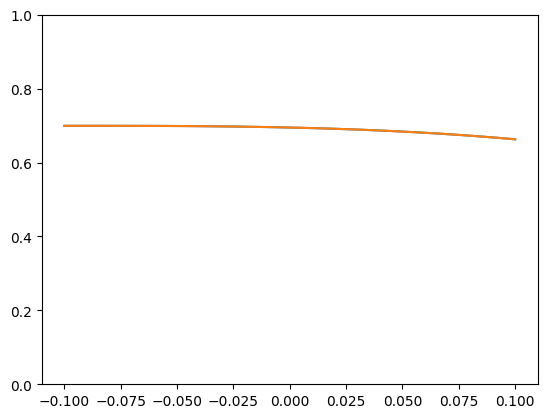

In [189]:
dat=[]
for t,p in zip(times,psi_t.T):
    dat.append( abs(1/4-np.vdot(p,Pn(2,"z",basis)@p)))

plot(times,dat)
ylim(0,1)
dat=[]
for t,p in zip(times,psi_t.T):
    dat.append( abs(1/4-np.vdot(p,fin_string(2,"z")@p)))

plot(times,dat)
ylim(0,1)

In [90]:
import numpy as np
from quspin.basis import spin_basis_1d

basis = spin_basis_1d(L, pauli=False)
Ns = basis.Ns

x_pattern = np.array([+1, +1, +1, +1,+1,+1,+1,+1,+1,+1])

psi = np.zeros(Ns, dtype=complex)

for s in range(Ns):
    # z spins: +1 (up) or -1 (down)
    z = basis.int_to_state(s)
    amp = 1.0
    for i in range(L):
        if x_pattern[i] == -1:
            amp *= z[i]
    psi[s] = amp

psi /= np.sqrt(2**L)


In [91]:
P = Pn(2,"x",basis)

np.vdot(psi,P@psi)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/255311436.py:3: RuntimeWarning: divide by zero encountered in matmul
  np.vdot(psi,P@psi)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/255311436.py:3: RuntimeWarning: overflow encountered in matmul
  np.vdot(psi,P@psi)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_10368/255311436.py:3: RuntimeWarning: invalid value encountered in matmul
  np.vdot(psi,P@psi)


np.complex128(0.5625+0j)

In [92]:
def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return array(O.todense())

In [209]:
import numpy as np
from quspin.basis import spin_basis_1d
L = 8
basis = spin_basis_1d(L)

# Define the single-site vectors in Z-basis
plus = np.array([1.0, 1.0]) / np.sqrt(2)
minus = np.array([1.0, -1.0]) / np.sqrt(2)

# Define your desired pattern in the X-basis
# Example: |+ - - +>
pattern = [plus,plus,minus,plus,minus,plus,minus,plus]

# Use Kronecker product to build the multi-site state
psi_x = pattern[0]
for i in range(1, L):
    psi_x = np.kron(psi_x, pattern[i])

# Now psi_x is a vector of size 2^L, ready for QuSpin
#print(f"State vector:\n{psi_x}")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


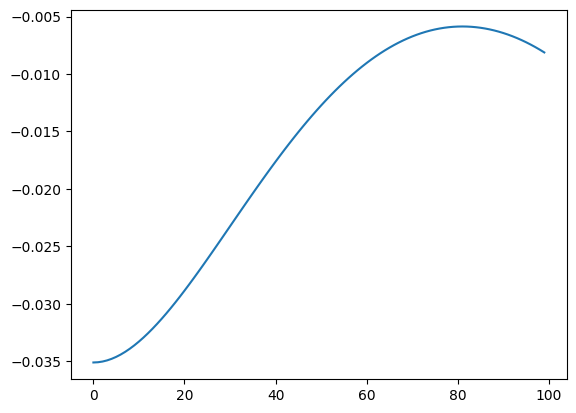

In [210]:
n=10
P = Pn(n,"z",basis)
Pav = fin_string(n,"z")
plot([np.vdot(psi_x,p) for p in psi_t.T])


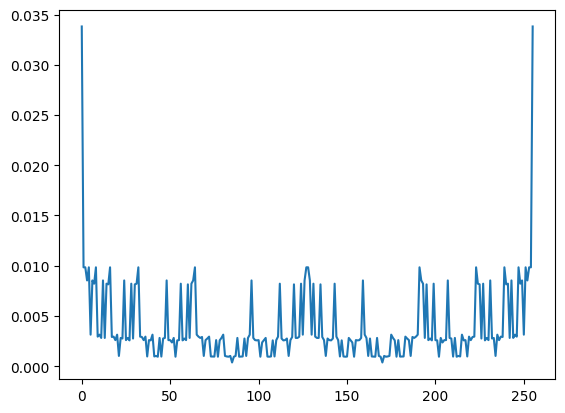

In [190]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d


# 1. Build the Operator that performs the basis change
# We use the fact that the Hadamard gate H = (Sx + Sz) * sqrt(2) 
# But it's easier to just build it as a dense matrix for small L:
h = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
U = h
for _ in range(L-1):
    U = np.kron(U, h)

# 2. Transform your state
# If psi_z is your state in the Z-basis (e.g. from a quench)
psi_x = U.dot(psi_t[:,-1])

plot(abs(psi_x)**2)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


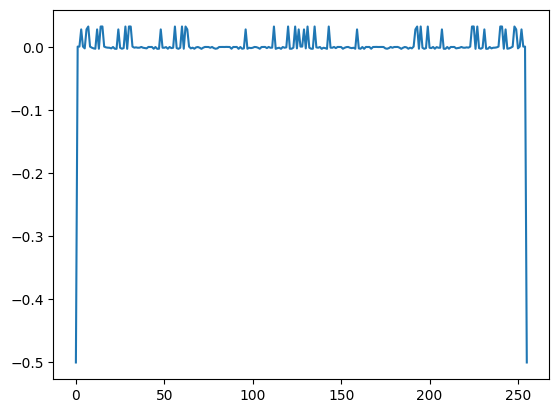